# btc_5m.ipynb - Dataset-only TD(lambda) DQN for BTC 5m Polymarket

Updated: 2026-05-13 00:29 KST

This Colab notebook assumes the processed dataset is already available: `btc_5m_finrl_state_long.pkl` or `btc_5m_finrl_state_long.csv`.

It intentionally does not download Binance data and does not rebuild the dataset from raw Polymarket files.

Lag experiment condition: no-lag reference. Polymarket lag, when enabled, affects observed features only; execution uses current-row prices.
Capital/trade defaults: `initial_cash=100`, no hard max-trade cap, each buy action purchases exactly 1 contract/share at the current Polymarket price, and learning rewards are scaled by `1 / initial_cash`.

Design note: Polymarket observations/actions stay on a 1-minute grid. Binance features are grouped separately so later sub-minute Binance summaries can be added as minute-aligned columns, for example `btc_30s_*`, `btc_10s_*`, or `binance_5s_*`, without changing the environment loop.

## Cell Chunks

| Chunk | Purpose |
|---|---|
| 1. Setup | Imports, Colab/Drive options, GPU detection, seed, timing and feature hyperparameters |
| 2. Dataset Load | Find/upload the processed dataset and choose feature columns by source group |
| 3. Feature Timing | Check missingness, keep Binance features unlagged by default, and apply past-only imputation |
| 4. Environment | Define the 5-step Polymarket trading environment |
| 5. Agents | Define shared dueling Q-network, TD(lambda) DQN, and replay-based Double Dueling DQN |
| 6. Evaluation Helpers | Walk-forward splits, scaling, random/directional baselines, summaries |
| 7. Training Helpers | Train and evaluate TD(lambda) DQN by fold |
| 8. Run Experiment | Run baselines, TD(lambda) DQN, Double Dueling DQN, save outputs |
| 9. Plot | Summarize profit and hold-only behavior |


In [1]:
# 1. Setup
import random
import time
from collections import deque, namedtuple
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    files = None
    drive = None
    IN_COLAB = False

USE_GOOGLE_DRIVE = False
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/dqn_project"
AUTO_UPLOAD_IF_MISSING = True

N_SPLITS = 5
TRAIN_RATIO = 0.6
EPISODES_PER_FOLD = 5000
LOG_EVERY = 500
RUN_BASELINES = True
RUN_TD_LAMBDA_DQN = True
RUN_DOUBLE_DUELING_DQN = True

# Timing model.
# Polymarket is assumed to be observable only at a 1-minute grid.
# Binance can later be represented by sub-minute features as long as they are pre-aggregated
# into columns on the same Polymarket minute rows.
POLY_OBSERVATION_INTERVAL_SECONDS = 60
DECISION_INTERVAL_SECONDS = 60
BINANCE_FEATURE_INTERVAL_SECONDS = 60

# Point-in-time safety switches.
# Binance lag shifts Binance model features to the previous completed candle when enabled.
USE_OBSERVATION_SAFE_BTC_LAG = False
BINANCE_FEATURE_LAG_SECONDS = BINANCE_FEATURE_INTERVAL_SECONDS if USE_OBSERVATION_SAFE_BTC_LAG else 0

# Polymarket lag shifts only observed Polymarket model features.
# Execution/mark-to-market prices stay on the current row via exec_poly_* columns.
USE_POLYMARKET_FEATURE_LAG = False
POLYMARKET_FEATURE_LAG_SECONDS = POLY_OBSERVATION_INTERVAL_SECONDS if USE_POLYMARKET_FEATURE_LAG else 0

USE_PAST_MEAN_IMPUTATION = True
DROP_POTENTIALLY_LEAKY_POLY_VOLUME = True

# Extra Binance feature prefixes for future sub-minute experiments.
AUTO_INCLUDE_EXTRA_BINANCE_FEATURES = True
EXTRA_BINANCE_FEATURE_PREFIXES = (
    "btc_subminute_",
    "btc_30s_",
    "btc_15s_",
    "btc_10s_",
    "btc_5s_",
    "binance_subminute_",
    "binance_30s_",
    "binance_15s_",
    "binance_10s_",
    "binance_5s_",
)

INITIAL_CASH = 100.0
MAX_TRADES = None
TRADE_UNITS = 1.0
MIN_TRADE_CASH = 1e-6
TRANSACTION_COST_PCT = 0.002
REWARD_SCALING = 1.0 / INITIAL_CASH

TRACE_LAMBDA = 0.85
DOUBLE_DQN_BATCH_SIZE = 64
DOUBLE_DQN_REPLAY_SIZE = 50_000
DOUBLE_DQN_WARMUP_STEPS = 256
REWARD_MODE = "terminal"
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if IN_COLAB and USE_GOOGLE_DRIVE:
    drive.mount("/content/drive")
    PROJECT_ROOT = Path(DRIVE_PROJECT_DIR)
elif IN_COLAB:
    PROJECT_ROOT = Path("/content/dqn_project")
else:
    cwd = Path.cwd()
    candidates = [cwd, *cwd.parents]
    PROJECT_ROOT = next((p for p in candidates if (p / "data" / "processed").exists()), cwd)

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "btc" / "5m"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)
print("torch:", torch.__version__)
print("capital/trade settings:", {
    "initial_cash": INITIAL_CASH,
    "max_trades": MAX_TRADES,
    "trade_units": TRADE_UNITS,
    "min_trade_cash": MIN_TRADE_CASH,
    "transaction_cost_pct": TRANSACTION_COST_PCT,
    "reward_scaling": REWARD_SCALING,
})
print("timing settings:", {
    "polymarket_interval_sec": POLY_OBSERVATION_INTERVAL_SECONDS,
    "decision_interval_sec": DECISION_INTERVAL_SECONDS,
    "binance_feature_interval_sec": BINANCE_FEATURE_INTERVAL_SECONDS,
    "binance_lag_enabled": USE_OBSERVATION_SAFE_BTC_LAG,
    "binance_lag_sec": BINANCE_FEATURE_LAG_SECONDS,
    "polymarket_lag_enabled": USE_POLYMARKET_FEATURE_LAG,
    "polymarket_lag_sec": POLYMARKET_FEATURE_LAG_SECONDS,
})


IN_COLAB: True
PROJECT_ROOT: /content/dqn_project
DEVICE: cuda
torch: 2.10.0+cu128
capital/trade settings: {'initial_cash': 100.0, 'max_trades': None, 'trade_units': 1.0, 'min_trade_cash': 1e-06, 'transaction_cost_pct': 0.002, 'reward_scaling': 0.01}
timing settings: {'polymarket_interval_sec': 60, 'decision_interval_sec': 60, 'binance_feature_interval_sec': 60, 'binance_lag_enabled': False, 'binance_lag_sec': 0, 'polymarket_lag_enabled': False, 'polymarket_lag_sec': 0}


In [2]:
# 2. Dataset Load
CANON_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "btc" / "5m" / "btc_5m_finrl_state_long.pkl"
CANON_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "btc" / "5m" / "btc_5m_finrl_state_long.pkl",
    PROJECT_ROOT / "data" / "processed" / "btc" / "5m" / "btc_5m_finrl_state_long.csv",
    PROJECT_ROOT / "btc_5m_finrl_state_long.pkl",
    PROJECT_ROOT / "btc_5m_finrl_state_long.csv",
    Path.cwd() / "btc_5m_finrl_state_long.pkl",
    Path.cwd() / "btc_5m_finrl_state_long.csv",
]
if IN_COLAB:
    DATA_CANDIDATES.extend([
        Path("/content/btc_5m_finrl_state_long.pkl"),
        Path("/content/btc_5m_finrl_state_long.csv"),
    ])


def find_state_file():
    for candidate in DATA_CANDIDATES:
        if candidate.exists():
            return candidate
    if IN_COLAB and AUTO_UPLOAD_IF_MISSING:
        print("Upload btc_5m_finrl_state_long.pkl or btc_5m_finrl_state_long.csv")
        files.upload()
        for candidate in DATA_CANDIDATES:
            if candidate.exists():
                return candidate
    return None


def read_state_file(path):
    path = Path(path)
    if path.suffix.lower() == ".pkl":
        return pd.read_pickle(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported dataset file: {path}")


state_path = find_state_file()
if state_path is None:
    raise FileNotFoundError("Could not find btc_5m_finrl_state_long.pkl/csv. Upload it in Colab or place it next to this notebook.")

state_df = read_state_file(state_path).sort_values(["market_slot_epoch", "minute_idx"]).reset_index(drop=True)
if state_path.resolve() != CANON_DATA_PATH.resolve():
    state_df.to_pickle(CANON_DATA_PATH)

POLY_FEATURE_CANDIDATES = [
    "poly_yes_price",
    "poly_overround",
    "poly_market_volume_log1p",
]
TIME_FEATURE_CANDIDATES = [
    "remaining_time_ratio",
]
BASE_BINANCE_FEATURE_CANDIDATES = [
    "btc_return",
    "btc_return_from_market_start",
    "btc_range_1m",
    "btc_quote_volume_log1p",
    "btc_volume_log1p",
    "btc_taker_buy_ratio",
]
BINANCE_RAW_OR_TARGET_EXCLUDES = {
    "btc_open",
    "btc_high",
    "btc_low",
    "btc_close",
    "btc_quote_volume",
    "btc_volume",
    "btc_taker_buy_base_volume",
    "btc_taker_buy_quote_volume",
    "btc_number_of_trades",
    "binance_slot_epoch",
}


def is_extra_binance_feature(column):
    return AUTO_INCLUDE_EXTRA_BINANCE_FEATURES and any(
        column.startswith(prefix) for prefix in EXTRA_BINANCE_FEATURE_PREFIXES
    )


def is_numeric_feature(df, column):
    return column in df.columns and pd.api.types.is_numeric_dtype(df[column])


def select_model_feature_cols(df):
    feature_cols = []
    feature_groups = []

    def add(column, group):
        if column in feature_cols:
            return
        if is_numeric_feature(df, column):
            feature_cols.append(column)
            feature_groups.append({"column": column, "group": group})

    for column in POLY_FEATURE_CANDIDATES:
        add(column, "polymarket_1m")
    for column in TIME_FEATURE_CANDIDATES:
        add(column, "time")
    for column in BASE_BINANCE_FEATURE_CANDIDATES:
        add(column, f"binance_{BINANCE_FEATURE_INTERVAL_SECONDS}s")

    for column in df.columns:
        if column in BINANCE_RAW_OR_TARGET_EXCLUDES:
            continue
        if is_extra_binance_feature(column):
            add(column, "binance_extra_subminute")

    if DROP_POTENTIALLY_LEAKY_POLY_VOLUME and "poly_market_volume_log1p" in feature_cols:
        feature_cols.remove("poly_market_volume_log1p")
        feature_groups = [row for row in feature_groups if row["column"] != "poly_market_volume_log1p"]
        print("Dropped poly_market_volume_log1p from model features because closed-market total volume may be future information.")

    return feature_cols, pd.DataFrame(feature_groups)


FEATURE_COLS, FEATURE_GROUPS = select_model_feature_cols(state_df)
if not FEATURE_COLS:
    raise ValueError("No usable numeric model features were found.")

MODEL_BINANCE_FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c.startswith("btc_") or c.startswith("binance_")
]
BTC_MARKET_RELATIVE_FEATURE_COLS = [
    c for c in MODEL_BINANCE_FEATURE_COLS
    if c in {"btc_return_from_market_start"}
]
BTC_POINT_FEATURE_COLS = [
    c for c in MODEL_BINANCE_FEATURE_COLS
    if c not in BTC_MARKET_RELATIVE_FEATURE_COLS
]

print("Feature groups:")
display(FEATURE_GROUPS)

required_cols = {"market_slot_epoch", "minute_idx", "slot_utc", "asset", "outcome", "poly_yes_price", "poly_overround", *FEATURE_COLS}
missing = sorted(required_cols - set(state_df.columns))
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")


def preserve_execution_price_columns(df):
    """Keep current-row Polymarket prices for execution even if observed features are lagged."""
    out = df.copy()
    if "exec_poly_yes_price" not in out.columns:
        out["exec_poly_yes_price"] = out["poly_yes_price"].astype(float)
    if "exec_poly_no_price" not in out.columns:
        if "poly_no_price" in out.columns:
            out["exec_poly_no_price"] = out["poly_no_price"].astype(float)
        else:
            out["exec_poly_no_price"] = 1.0 + out["poly_overround"].astype(float) - out["poly_yes_price"].astype(float)
    return out


state_df = preserve_execution_price_columns(state_df)

print("loaded:", state_path)
print("canonical path:", CANON_DATA_PATH)
print("state_df:", state_df.shape)
print("markets:", state_df["market_slot_epoch"].nunique())
print("features:", FEATURE_COLS)
print("outcome counts:")
print(state_df.drop_duplicates("market_slot_epoch")["outcome"].value_counts().sort_index())
display(state_df.head())


Upload btc_5m_finrl_state_long.pkl or btc_5m_finrl_state_long.csv


Saving btc_5m_finrl_state_long.csv to btc_5m_finrl_state_long.csv
Dropped poly_market_volume_log1p from model features because closed-market total volume may be future information.
Feature groups:


,column,group
0,poly_yes_price,polymarket_1m
1,poly_overround,polymarket_1m
2,remaining_time_ratio,time
3,btc_return,binance_60s
4,btc_return_from_market_start,binance_60s
5,btc_range_1m,binance_60s
6,btc_volume_log1p,binance_60s
7,btc_taker_buy_ratio,binance_60s


loaded: /content/btc_5m_finrl_state_long.csv
canonical path: /content/dqn_project/data/processed/btc/5m/btc_5m_finrl_state_long.pkl
state_df: (89275, 17)
markets: 17855
features: ['poly_yes_price', 'poly_overround', 'remaining_time_ratio', 'btc_return', 'btc_return_from_market_start', 'btc_range_1m', 'btc_volume_log1p', 'btc_taker_buy_ratio']
outcome counts:
outcome
0    8899
1    8956
Name: count, dtype: int64


,market_slot_epoch,minute_idx,minute_slot_epoch,slot_utc,asset,outcome,poly_yes_price,poly_overround,poly_market_volume_log1p,remaining_time_ratio,btc_return,btc_return_from_market_start,btc_range_1m,btc_volume_log1p,btc_taker_buy_ratio,exec_poly_yes_price,exec_poly_no_price
0,1771459800,0,1771459800,2026-02-19T00:10:00+00:00,bitcoin,0,0.485,0.000,11.496993,1.0,-0.000012,-0.000012,0.000275,1.390309,0.620147,0.485,0.515
1,1771459800,1,1771459860,2026-02-19T00:10:00+00:00,bitcoin,0,0.465,0.010,11.496993,0.8,-0.000057,-0.000070,0.000318,2.492654,0.451803,0.465,0.545
2,1771459800,2,1771459920,2026-02-19T00:10:00+00:00,bitcoin,0,0.345,0.000,11.496993,0.6,-0.000694,-0.000764,0.000694,1.687323,0.387050,0.345,0.655
3,1771459800,3,1771459980,2026-02-19T00:10:00+00:00,bitcoin,0,0.120,-0.005,11.496993,0.4,-0.001391,-0.002154,0.001440,2.178272,0.098492,0.120,0.875
4,1771459800,4,1771460040,2026-02-19T00:10:00+00:00,bitcoin,0,0.005,0.000,11.496993,0.2,0.000053,-0.002101,0.000054,1.120070,0.653276,0.005,0.995


In [3]:
# 3. Feature Timing and Missingness Diagnostics
DIAGNOSTIC_FEATURE_COLS = list(dict.fromkeys([
    *POLY_FEATURE_CANDIDATES,
    *TIME_FEATURE_CANDIDATES,
    *BASE_BINANCE_FEATURE_CANDIDATES,
    *FEATURE_COLS,
]))
DIAGNOSTIC_FEATURE_COLS = [c for c in DIAGNOSTIC_FEATURE_COLS if c in state_df.columns]


def missingness_report(df, columns=None):
    if columns is None:
        columns = list(df.columns)
    report = pd.DataFrame({
        "column": columns,
        "missing_count": [int(df[c].isna().sum()) for c in columns],
        "missing_ratio": [float(df[c].isna().mean()) for c in columns],
        "dtype": [str(df[c].dtype) for c in columns],
    })
    return report.sort_values(["missing_count", "column"], ascending=[False, True]).reset_index(drop=True)


print("Missingness across all columns:")
display(missingness_report(state_df))
print("Missingness across candidate/model features:")
display(missingness_report(state_df, DIAGNOSTIC_FEATURE_COLS))


def apply_observation_safe_btc_lag(df):
    """Use only Binance information that would be known before the current decision row.

    When BINANCE_FEATURE_LAG_SECONDS=0, Binance features are used from the same row.
    For future sub-minute Binance features, pre-aggregate them to the 1-minute Polymarket
    decision rows and set BINANCE_FEATURE_LAG_SECONDS to the correct observation delay.
    """
    out = df.sort_values(["market_slot_epoch", "minute_idx"]).copy()
    if BINANCE_FEATURE_LAG_SECONDS <= 0:
        print("BINANCE_FEATURE_LAG_SECONDS <= 0; Binance features are assumed point-in-time safe.")
        return out
    if "minute_slot_epoch" not in out.columns:
        print("minute_slot_epoch is missing; cannot lag Binance features. Skipping Binance lag.")
        return out

    point_cols = [c for c in BTC_POINT_FEATURE_COLS if c in out.columns]
    for col in point_cols:
        mapping = (
            out[["minute_slot_epoch", col]]
            .drop_duplicates("minute_slot_epoch", keep="last")
            .set_index("minute_slot_epoch")[col]
        )
        out[col] = (out["minute_slot_epoch"] - BINANCE_FEATURE_LAG_SECONDS).map(mapping)

    for col in BTC_MARKET_RELATIVE_FEATURE_COLS:
        if col in out.columns:
            out[col] = (
                out.groupby("market_slot_epoch", sort=False)[col]
                .shift(max(BINANCE_FEATURE_LAG_SECONDS // max(DECISION_INTERVAL_SECONDS, 1), 1))
                .fillna(0.0)
            )

    print("Lagged Binance point features:", point_cols)
    print("Lagged Binance market-relative features:", BTC_MARKET_RELATIVE_FEATURE_COLS)
    return out


def apply_polymarket_observation_lag(df):
    """Lag only observed Polymarket model features; keep exec_poly_* current-row prices."""
    out = df.sort_values(["market_slot_epoch", "minute_idx"]).copy()
    if POLYMARKET_FEATURE_LAG_SECONDS <= 0:
        print("POLYMARKET_FEATURE_LAG_SECONDS <= 0; Polymarket features are assumed point-in-time safe.")
        return out

    lag_steps = max(POLYMARKET_FEATURE_LAG_SECONDS // max(DECISION_INTERVAL_SECONDS, 1), 1)
    poly_cols = [c for c in ["poly_yes_price", "poly_overround", "poly_market_volume_log1p"] if c in out.columns]
    for col in poly_cols:
        out[col] = out.groupby("market_slot_epoch", sort=False)[col].shift(lag_steps)
    if "poly_no_price" in out.columns:
        out["poly_no_price"] = out.groupby("market_slot_epoch", sort=False)["poly_no_price"].shift(lag_steps)

    print("Lagged Polymarket observation features:", poly_cols)
    print("Execution prices kept current-row via exec_poly_yes_price/exec_poly_no_price.")
    return out


def impute_features_with_past_mean(df, feature_cols, time_cols=("minute_slot_epoch", "market_slot_epoch", "minute_idx")):
    """Fill feature NaNs with the expanding mean from strictly earlier rows."""
    sort_cols = [c for c in time_cols if c in df.columns]
    out = df.sort_values(sort_cols).copy() if sort_cols else df.copy()
    imputation_rows = []

    for col in feature_cols:
        values = pd.to_numeric(out[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        missing_before = int(values.isna().sum())
        past_mean = values.expanding(min_periods=1).mean().shift(1)
        filled = values.fillna(past_mean)
        fallback = filled.dropna().iloc[0] if filled.notna().any() else 0.0
        filled = filled.fillna(fallback)
        out[col] = filled.astype(float)
        imputation_rows.append({
            "column": col,
            "missing_before": missing_before,
            "missing_after": int(out[col].isna().sum()),
            "fallback_for_initial_missing": float(fallback),
        })

    out = out.sort_values(["market_slot_epoch", "minute_idx"]).reset_index(drop=True)
    return out, pd.DataFrame(imputation_rows)


if USE_POLYMARKET_FEATURE_LAG:
    state_df = apply_polymarket_observation_lag(state_df)
    print(f"Applied Polymarket observation lag: lag_seconds={POLYMARKET_FEATURE_LAG_SECONDS}.")
    print("Missingness after Polymarket lag, before imputation:")
    display(missingness_report(state_df, DIAGNOSTIC_FEATURE_COLS))

if USE_OBSERVATION_SAFE_BTC_LAG:
    state_df = apply_observation_safe_btc_lag(state_df)
    print(f"Applied observation-safe Binance lag: lag_seconds={BINANCE_FEATURE_LAG_SECONDS}.")
    print("Missingness after BTC lag, before imputation:")
    display(missingness_report(state_df, DIAGNOSTIC_FEATURE_COLS))

if USE_PAST_MEAN_IMPUTATION:
    state_df, imputation_report = impute_features_with_past_mean(state_df, FEATURE_COLS)
    print("Applied past-only expanding-mean imputation to model features.")
    display(imputation_report)
    print("Missingness after imputation:")
    display(missingness_report(state_df, FEATURE_COLS))


Missingness across all columns:


,column,missing_count,missing_ratio,dtype
0,poly_market_volume_log1p,29185,0.326911,float64
1,asset,0,0.000000,object
2,btc_range_1m,0,0.000000,float64
3,btc_return,0,0.000000,float64
4,btc_return_from_market_start,0,0.000000,float64
5,btc_taker_buy_ratio,0,0.000000,float64
6,btc_volume_log1p,0,0.000000,float64
7,exec_poly_no_price,0,0.000000,float64
8,exec_poly_yes_price,0,0.000000,float64
9,market_slot_epoch,0,0.000000,int64


Missingness across candidate/model features:


,column,missing_count,missing_ratio,dtype
0,poly_market_volume_log1p,29185,0.326911,float64
1,btc_range_1m,0,0.000000,float64
2,btc_return,0,0.000000,float64
3,btc_return_from_market_start,0,0.000000,float64
4,btc_taker_buy_ratio,0,0.000000,float64
5,btc_volume_log1p,0,0.000000,float64
6,poly_overround,0,0.000000,float64
7,poly_yes_price,0,0.000000,float64
8,remaining_time_ratio,0,0.000000,float64


Applied past-only expanding-mean imputation to model features.


,column,missing_before,missing_after,fallback_for_initial_missing
0,poly_yes_price,0,0,0.485000
1,poly_overround,0,0,0.000000
2,remaining_time_ratio,0,0,1.000000
3,btc_return,0,0,-0.000012
4,btc_return_from_market_start,0,0,-0.000012
5,btc_range_1m,0,0,0.000275
6,btc_volume_log1p,0,0,1.390309
7,btc_taker_buy_ratio,0,0,0.620147


Missingness after imputation:


,column,missing_count,missing_ratio,dtype
0,btc_range_1m,0,0.0,float64
1,btc_return,0,0.0,float64
2,btc_return_from_market_start,0,0.0,float64
3,btc_taker_buy_ratio,0,0.0,float64
4,btc_volume_log1p,0,0.0,float64
5,poly_overround,0,0.0,float64
6,poly_yes_price,0,0.0,float64
7,remaining_time_ratio,0,0.0,float64


In [4]:
# 4. Environment
DEFAULT_PORTFOLIO_FEATURES = [
    "cash_ratio",
    "portfolio_value_ratio",
    "net_position_value_ratio",
    "trades_remaining_ratio",
]


class PolymarketBTC5mEnv:
    HOLD = 0
    BUY_UP = 1
    BUY_DOWN = 2
    ACTION_DIM = 3

    def __init__(
        self,
        data,
        feature_cols,
        feature_means=None,
        feature_stds=None,
        initial_cash=1.0,
        max_trades=None,
        trade_units=1.0,
        min_trade_cash=1e-6,
        transaction_cost_pct=0.002,
        reward_mode="terminal",
        reward_scaling=1.0,
        seed=SEED,
        market_ids=None,
        portfolio_feature_cols=None,
    ):
        self.df = data.copy() if isinstance(data, pd.DataFrame) else read_state_file(data)
        self.df = self.df.sort_values(["market_slot_epoch", "minute_idx"]).reset_index(drop=True)
        if "poly_no_price" not in self.df.columns:
            self.df["poly_no_price"] = 1.0 + self.df["poly_overround"] - self.df["poly_yes_price"]
        if "exec_poly_yes_price" not in self.df.columns:
            self.df["exec_poly_yes_price"] = self.df["poly_yes_price"]
        if "exec_poly_no_price" not in self.df.columns:
            self.df["exec_poly_no_price"] = self.df["poly_no_price"]

        self.feature_cols = list(feature_cols)
        self.feature_means = None if feature_means is None else np.asarray(feature_means, dtype=np.float32)
        self.feature_stds = None if feature_stds is None else np.asarray(feature_stds, dtype=np.float32)
        self.portfolio_feature_cols = list(portfolio_feature_cols or DEFAULT_PORTFOLIO_FEATURES)
        self.initial_cash = float(initial_cash)
        self.max_trades = None if max_trades is None else int(max_trades)
        self.trade_units = float(trade_units)
        self.min_trade_cash = float(min_trade_cash)
        self.transaction_cost_pct = float(transaction_cost_pct)
        if self.trade_units <= 0:
            raise ValueError("trade_units must be positive")
        self.action_specs = {
            self.HOLD: {"side": "hold"},
            self.BUY_UP: {"side": "up"},
            self.BUY_DOWN: {"side": "down"},
        }
        self.reward_mode = reward_mode
        self.reward_scaling = float(reward_scaling)
        if self.reward_mode not in {"terminal", "mark_to_market"}:
            raise ValueError("reward_mode must be 'terminal' or 'mark_to_market'")

        all_market_ids = self.df["market_slot_epoch"].drop_duplicates().to_numpy()
        if market_ids is None:
            self.market_ids = all_market_ids
        else:
            requested = np.array(list(market_ids), dtype=np.int64)
            available = set(all_market_ids.tolist())
            self.market_ids = np.array([m for m in requested if int(m) in available], dtype=np.int64)
            if len(self.market_ids) == 0:
                raise ValueError("market_ids did not match any market in data")

        self.rng = np.random.default_rng(seed)
        self.current_market_id = None
        self.market = None
        self.t = 0
        self.cash = self.initial_cash
        self.up_shares = 0.0
        self.down_shares = 0.0
        self.trades_used = 0
        self.done = False

    @property
    def n_actions(self):
        return self.ACTION_DIM

    @property
    def state_dim(self):
        return len(self.feature_cols) + len(self.portfolio_feature_cols)

    def action_side(self, action):
        return self.action_specs.get(int(action), self.action_specs[self.HOLD])["side"]

    def count_actions_by_side(self, actions, side):
        return sum(1 for action in actions if self.action_side(action) == side)

    def reset(self, market_id=None):
        if market_id is None:
            market_id = self.rng.choice(self.market_ids)
        self.current_market_id = int(market_id)
        self.market = (
            self.df[self.df["market_slot_epoch"] == self.current_market_id]
            .sort_values("minute_idx")
            .reset_index(drop=True)
        )
        if len(self.market) != 5:
            raise ValueError(f"Expected 5 rows for market {market_id}, got {len(self.market)}")
        self.t = 0
        self.cash = self.initial_cash
        self.up_shares = 0.0
        self.down_shares = 0.0
        self.trades_used = 0
        self.done = False
        return self._get_state()

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode is done. Call reset().")
        action = int(action)
        row = self.market.iloc[self.t]
        equity_before = self._mark_to_market_value(row)
        trade_info = self._execute_action(action, row)

        if self.t == len(self.market) - 1:
            self.done = True
            reward_raw = self._settlement_value() - self.initial_cash if self.reward_mode == "terminal" else self._settlement_value() - equity_before
            next_state = None
        else:
            self.t += 1
            next_row = self.market.iloc[self.t]
            next_state = self._get_state()
            reward_raw = self._mark_to_market_value(next_row) - equity_before if self.reward_mode == "mark_to_market" else 0.0

        reward = reward_raw * self.reward_scaling
        info = {
            "market_slot_epoch": self.current_market_id,
            "minute_idx": int(row["minute_idx"]),
            "action": action,
            "action_side": self.action_side(action),
            "cash": self.cash,
            "up_shares": self.up_shares,
            "down_shares": self.down_shares,
            "trades_used": self.trades_used,
            "trade_executed": trade_info["executed"],
            "trade_cost": trade_info["cost"],
            "trade_spend": trade_info["spend"],
            "trade_price": trade_info["price"],
            "trade_shares": trade_info["shares"],
            "raw_reward": reward_raw,
            "settlement_value": self._settlement_value() if self.done else None,
            "profit": self._settlement_value() - self.initial_cash if self.done else None,
            "portfolio_value": self._mark_to_market_value(row),
            "outcome": int(row["outcome"]),
            "valid_action_mask": self.valid_action_mask(),
        }
        return next_state, reward, self.done, info

    def _contract_total_cost(self, price):
        contract_cost = float(price) * self.trade_units
        return contract_cost + contract_cost * self.transaction_cost_pct

    def _execute_action(self, action, row):
        trade_limit_reached = self.max_trades is not None and self.trades_used >= self.max_trades
        side = self.action_side(action)
        if side == "hold" or trade_limit_reached:
            return {"executed": False, "cost": 0.0, "spend": 0.0, "price": 0.0, "shares": 0.0}
        price_col = "exec_poly_yes_price" if side == "up" else "exec_poly_no_price"
        price = float(row[price_col])
        if price <= 0:
            return {"executed": False, "cost": 0.0, "spend": 0.0, "price": price, "shares": 0.0}
        contract_cost = price * self.trade_units
        fee = contract_cost * self.transaction_cost_pct
        spend = contract_cost + fee
        if spend <= self.min_trade_cash or self.cash < spend:
            return {"executed": False, "cost": 0.0, "spend": 0.0, "price": price, "shares": 0.0}
        self.cash -= spend
        if side == "up":
            self.up_shares += self.trade_units
        else:
            self.down_shares += self.trade_units
        self.trades_used += 1
        return {"executed": True, "cost": fee, "spend": spend, "price": price, "shares": self.trade_units}

    def _mark_to_market_value(self, row):
        return self.cash + self.up_shares * float(row["exec_poly_yes_price"]) + self.down_shares * float(row["exec_poly_no_price"])

    def _settlement_value(self):
        outcome = int(self.market.iloc[-1]["outcome"])
        return self.cash + self.up_shares * float(outcome == 1) + self.down_shares * float(outcome == 0)

    def valid_action_mask(self):
        trade_limit_reached = self.max_trades is not None and self.trades_used >= self.max_trades
        if trade_limit_reached or self.market is None or self.done:
            return np.array([True, False, False], dtype=bool)
        row = self.market.iloc[self.t]
        can_buy_up = self.cash >= self._contract_total_cost(float(row["exec_poly_yes_price"]))
        can_buy_down = self.cash >= self._contract_total_cost(float(row["exec_poly_no_price"]))
        return np.array([True, can_buy_up, can_buy_down], dtype=bool)

    def _get_portfolio_state_dict(self, row):
        up_value = self.up_shares * float(row["exec_poly_yes_price"])
        down_value = self.down_shares * float(row["exec_poly_no_price"])
        gross_value = up_value + down_value
        portfolio_value = self.cash + gross_value
        return {
            "cash_ratio": self.cash / self.initial_cash,
            "portfolio_value_ratio": portfolio_value / self.initial_cash,
            "up_position_value_ratio": up_value / self.initial_cash,
            "down_position_value_ratio": down_value / self.initial_cash,
            "net_position_value_ratio": (up_value - down_value) / self.initial_cash,
            "gross_position_value_ratio": gross_value / self.initial_cash,
            "trades_used_ratio": 0.0 if self.max_trades is None else self.trades_used / max(self.max_trades, 1),
            "trades_remaining_ratio": 1.0 if self.max_trades is None and self.cash >= min(self._contract_total_cost(float(row["exec_poly_yes_price"])), self._contract_total_cost(float(row["exec_poly_no_price"]))) else ((self.max_trades - self.trades_used) / max(self.max_trades, 1) if self.max_trades is not None else 0.0),
        }

    def _get_state(self):
        row = self.market.iloc[self.t]
        market_state = row[self.feature_cols].to_numpy(dtype=np.float32)
        if self.feature_means is not None and self.feature_stds is not None:
            market_state = np.where(np.isfinite(market_state), market_state, self.feature_means)
            market_state = (market_state - self.feature_means) / self.feature_stds
        else:
            market_state = np.nan_to_num(market_state, nan=0.0, posinf=0.0, neginf=0.0)
        portfolio = self._get_portfolio_state_dict(row)
        portfolio_state = np.array([portfolio[col] for col in self.portfolio_feature_cols], dtype=np.float32)
        return np.concatenate([market_state, portfolio_state])


smoke_env = PolymarketBTC5mEnv(state_df, FEATURE_COLS, seed=SEED)
print("state_dim:", smoke_env.state_dim)
print("n_actions:", smoke_env.n_actions)
print("trade_units:", smoke_env.trade_units)
print("smoke state:", smoke_env.reset()[:8])


state_dim: 12
n_actions: 3
trade_units: 1.0
smoke state: [5.1999998e-01 4.9999999e-03 1.0000000e+00 1.3001586e-03 1.3001586e-03
 1.8950305e-03 2.5651140e+00 5.9781003e-01]


In [5]:
# 5. Agents
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim=3, hidden_dim=128):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.value = nn.Linear(hidden_dim, 1)
        self.advantage = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        h = self.feature(x)
        value = self.value(h)
        advantage = self.advantage(h)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


class DQNLambdaAgent:
    def __init__(
        self,
        state_dim,
        action_dim=3,
        hidden_dim=128,
        lr=1e-4,
        gamma=0.95,
        trace_lambda=TRACE_LAMBDA,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay_steps=30_000,
        target_update_interval=1_000,
        td_error_clip=5.0,
        grad_clip=10.0,
        device=DEVICE,
        seed=SEED,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = float(gamma)
        self.trace_lambda = float(trace_lambda)
        self.epsilon_start = float(epsilon_start)
        self.epsilon_end = float(epsilon_end)
        self.epsilon_decay_steps = int(epsilon_decay_steps)
        self.target_update_interval = int(target_update_interval)
        self.td_error_clip = float(td_error_clip)
        self.grad_clip = float(grad_clip)
        self.learn_steps = 0
        self.device = torch.device(device)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        self.online_net = DuelingQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.target_net = DuelingQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = torch.optim.AdamW(self.online_net.parameters(), lr=lr)
        self.traces = [torch.zeros_like(p, device=self.device) for p in self.online_net.parameters()]

    def epsilon(self):
        progress = min(self.learn_steps / max(self.epsilon_decay_steps, 1), 1.0)
        return self.epsilon_start + progress * (self.epsilon_end - self.epsilon_start)

    def start_episode(self):
        for trace in self.traces:
            trace.zero_()

    def select_action(self, state, valid_action_mask=None, evaluate=False):
        if valid_action_mask is None:
            valid_action_mask = np.ones(self.action_dim, dtype=bool)
        valid_actions = np.flatnonzero(valid_action_mask)
        if len(valid_actions) == 0:
            return 0
        if not evaluate and random.random() < self.epsilon():
            return int(np.random.choice(valid_actions))
        state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_net(state_t).squeeze(0)
        invalid_mask = torch.as_tensor(~valid_action_mask, dtype=torch.bool, device=self.device)
        q_values = q_values.masked_fill(invalid_mask, -1e9)
        return int(torch.argmax(q_values).item())

    def update_td_lambda(self, state, action, reward, next_state, done, next_valid_action_mask):
        state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        q_sa = self.online_net(state_t).squeeze(0)[int(action)]
        with torch.no_grad():
            if done or next_state is None:
                target = torch.tensor(float(reward), dtype=torch.float32, device=self.device)
            else:
                next_state_t = torch.as_tensor(next_state, dtype=torch.float32, device=self.device).unsqueeze(0)
                next_mask = torch.as_tensor(next_valid_action_mask, dtype=torch.bool, device=self.device)
                next_q_online = self.online_net(next_state_t).squeeze(0).masked_fill(~next_mask, -1e9)
                next_action = int(torch.argmax(next_q_online).item())
                next_q_target = self.target_net(next_state_t).squeeze(0)[next_action]
                target = torch.tensor(float(reward), dtype=torch.float32, device=self.device) + self.gamma * next_q_target
            td_error = target - q_sa.detach()
            clipped_td_error = td_error.clamp(-self.td_error_clip, self.td_error_clip)

        self.online_net.zero_grad(set_to_none=True)
        q_sa.backward()
        with torch.no_grad():
            for trace, param in zip(self.traces, self.online_net.parameters()):
                if param.grad is None:
                    continue
                trace.mul_(self.gamma * self.trace_lambda).add_(param.grad)
                param.grad.copy_(-clipped_td_error * trace)
        nn.utils.clip_grad_norm_(self.online_net.parameters(), self.grad_clip)
        self.optimizer.step()
        self.learn_steps += 1
        if self.learn_steps % self.target_update_interval == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return {
            "loss_like": float(0.5 * td_error.item() ** 2),
        }

Transition = namedtuple(
    "Transition",
    [
        "state",
        "action",
        "reward",
        "next_state",
        "done",
        "valid_action_mask",
        "next_valid_action_mask",
    ],
)


class ReplayBuffer:
    def __init__(self, capacity=DOUBLE_DQN_REPLAY_SIZE):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)


class DoubleDuelingDQNAgent:
    """Replay-based Double DQN agent using the shared dueling Q-network."""

    def __init__(
        self,
        state_dim,
        action_dim=3,
        hidden_dim=128,
        lr=3e-4,
        gamma=0.95,
        batch_size=DOUBLE_DQN_BATCH_SIZE,
        replay_size=DOUBLE_DQN_REPLAY_SIZE,
        warmup_steps=DOUBLE_DQN_WARMUP_STEPS,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay_steps=30_000,
        target_update_interval=1_000,
        device=DEVICE,
        seed=SEED,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = float(gamma)
        self.batch_size = int(batch_size)
        self.warmup_steps = int(warmup_steps)
        self.epsilon_start = float(epsilon_start)
        self.epsilon_end = float(epsilon_end)
        self.epsilon_decay_steps = int(epsilon_decay_steps)
        self.target_update_interval = int(target_update_interval)
        self.learn_steps = 0
        self.env_steps = 0
        self.device = torch.device(device)

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        self.online_net = DuelingQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.target_net = DuelingQNetwork(state_dim, action_dim, hidden_dim).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = torch.optim.AdamW(self.online_net.parameters(), lr=lr)
        self.replay = ReplayBuffer(replay_size)

    def epsilon(self):
        progress = min(self.env_steps / max(self.epsilon_decay_steps, 1), 1.0)
        return self.epsilon_start + progress * (self.epsilon_end - self.epsilon_start)

    def select_action(self, state, valid_action_mask=None, evaluate=False):
        if valid_action_mask is None:
            valid_action_mask = np.ones(self.action_dim, dtype=bool)
        valid_actions = np.flatnonzero(valid_action_mask)
        if len(valid_actions) == 0:
            return 0
        if not evaluate and random.random() < self.epsilon():
            return int(np.random.choice(valid_actions))

        state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_net(state_t).squeeze(0)
        invalid_mask = torch.as_tensor(~valid_action_mask, dtype=torch.bool, device=self.device)
        q_values = q_values.masked_fill(invalid_mask, -1e9)
        return int(torch.argmax(q_values).item())

    def remember(self, state, action, reward, next_state, done, valid_action_mask, next_valid_action_mask):
        if next_state is None:
            next_state = np.zeros_like(state, dtype=np.float32)
        if next_valid_action_mask is None:
            next_valid_action_mask = np.zeros(self.action_dim, dtype=bool)
        self.replay.push(
            np.asarray(state, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_state, dtype=np.float32),
            bool(done),
            np.asarray(valid_action_mask, dtype=bool),
            np.asarray(next_valid_action_mask, dtype=bool),
        )
        self.env_steps += 1

    def update(self):
        if len(self.replay) < max(self.batch_size, self.warmup_steps):
            return None

        batch = self.replay.sample(self.batch_size)
        states = torch.as_tensor(np.stack([b.state for b in batch]), dtype=torch.float32, device=self.device)
        actions = torch.as_tensor([b.action for b in batch], dtype=torch.long, device=self.device).unsqueeze(1)
        rewards = torch.as_tensor([b.reward for b in batch], dtype=torch.float32, device=self.device).unsqueeze(1)
        next_states = torch.as_tensor(np.stack([b.next_state for b in batch]), dtype=torch.float32, device=self.device)
        dones = torch.as_tensor([b.done for b in batch], dtype=torch.float32, device=self.device).unsqueeze(1)
        next_masks = torch.as_tensor(np.stack([b.next_valid_action_mask for b in batch]), dtype=torch.bool, device=self.device)

        q_sa = self.online_net(states).gather(1, actions)
        with torch.no_grad():
            next_q_online = self.online_net(next_states).masked_fill(~next_masks, -1e9)
            next_actions = next_q_online.argmax(dim=1, keepdim=True)
            next_q_target = self.target_net(next_states).gather(1, next_actions)
            target = rewards + self.gamma * (1.0 - dones) * next_q_target
        loss = nn.functional.smooth_l1_loss(q_sa, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        self.learn_steps += 1
        if self.learn_steps % self.target_update_interval == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return {
            "loss": float(loss.item()),
        }



In [6]:
# 6. Evaluation Helpers
def make_walk_forward_splits(market_ids, n_splits=N_SPLITS, train_ratio=TRAIN_RATIO):
    market_ids = np.array(sorted(market_ids), dtype=np.int64)
    n = len(market_ids)
    initial_train_size = int(n * train_ratio)
    test_size = (n - initial_train_size) // n_splits
    if initial_train_size <= 0 or test_size <= 0:
        raise ValueError("Not enough markets for the requested split settings.")
    splits = []
    for fold in range(n_splits):
        train_end = initial_train_size + fold * test_size
        test_start = train_end
        test_end = n if fold == n_splits - 1 else test_start + test_size
        train_ids = market_ids[:train_end]
        test_ids = market_ids[test_start:test_end]
        splits.append({
            "fold": fold + 1,
            "train_ids": train_ids,
            "test_ids": test_ids,
            "train_start": int(train_ids[0]),
            "train_end": int(train_ids[-1]),
            "test_start": int(test_ids[0]),
            "test_end": int(test_ids[-1]),
        })
    return splits


def fit_feature_scaler(df, market_ids, feature_cols):
    values = df.loc[df["market_slot_epoch"].isin(market_ids), feature_cols].astype(float)
    values = values.replace([np.inf, -np.inf], np.nan)
    means_s = values.mean().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    stds_s = values.std(ddof=0).replace([np.inf, -np.inf], np.nan).replace(0, 1.0).fillna(1.0)
    means = means_s.to_numpy(dtype=np.float32)
    stds = stds_s.to_numpy(dtype=np.float32)
    stds = np.where(np.abs(stds) < 1e-12, 1.0, stds).astype(np.float32)
    return means, stds


def summarize_episode_results(df):
    profits = df["profit"].astype(float)
    buy_up = df["num_buy_up"].astype(float)
    buy_down = df["num_buy_down"].astype(float)
    buy_count = buy_up + buy_down
    std_profit = profits.std(ddof=1)
    return {
        "episodes": int(len(df)),
        "mean_profit": float(profits.mean()),
        "median_profit": float(profits.median()),
        "total_profit": float(profits.sum()),
        "std_profit": float(std_profit),
        "win_rate": float((profits > 0).mean()),
        "sharpe_like": 0.0 if std_profit == 0 or np.isnan(std_profit) else float(profits.mean() / std_profit),
        "avg_settlement_value": float(df["settlement_value"].mean()),
        "avg_buy_up": float(buy_up.mean()),
        "avg_buy_down": float(buy_down.mean()),
        "hold_only_rate": float((buy_count == 0).mean()),
        "buy_up_rate": float((buy_up > 0).mean()),
        "buy_down_rate": float((buy_down > 0).mean()),
    }


def policy_random(env, state):
    valid_actions = np.flatnonzero(env.valid_action_mask())
    if len(valid_actions) == 0:
        return env.HOLD
    return int(env.rng.choice(valid_actions))


def policy_buy_yes_t0(env, state):
    return env.BUY_UP if env.t == 0 else env.HOLD


def policy_buy_no_t0(env, state):
    return env.BUY_DOWN if env.t == 0 else env.HOLD


def policy_market_price_t0(env, state):
    row = env.market.iloc[env.t]
    if env.t != 0:
        return env.HOLD
    return env.BUY_UP if row["poly_yes_price"] >= row["poly_no_price"] else env.BUY_DOWN


def policy_btc_momentum_t0(env, state):
    row = env.market.iloc[env.t]
    if env.t != 0:
        return env.HOLD
    return env.BUY_UP if row["btc_return"] >= 0 else env.BUY_DOWN


POLICIES = {
    "random": policy_random,
    "buy_yes_t0": policy_buy_yes_t0,
    "buy_no_t0": policy_buy_no_t0,
    "market_price_t0": policy_market_price_t0,
    "btc_momentum_t0": policy_btc_momentum_t0,
}


def run_actor_on_markets(actor, market_ids, env):
    rows = []
    for market_id in market_ids:
        state = env.reset(market_id=market_id)
        done = False
        total_reward = 0.0
        actions = []
        final_info = None
        while not done:
            action = actor(env, state)
            state, reward, done, info = env.step(action)
            total_reward += reward
            actions.append(action)
            final_info = info
        rows.append({
            "market_slot_epoch": int(market_id),
            "total_reward": total_reward,
            "settlement_value": final_info["settlement_value"],
            "profit": final_info["settlement_value"] - env.initial_cash,
            "outcome": final_info["outcome"],
            "num_buy_up": env.count_actions_by_side(actions, "up"),
            "num_buy_down": env.count_actions_by_side(actions, "down"),
            "num_hold": actions.count(env.HOLD),
        })
    return pd.DataFrame(rows)


market_ids = state_df["market_slot_epoch"].drop_duplicates().sort_values().to_numpy()
splits = make_walk_forward_splits(market_ids)
split_df = pd.DataFrame([
    {k: v for k, v in split.items() if not k.endswith("ids")} | {
        "train_size": len(split["train_ids"]),
        "test_size": len(split["test_ids"]),
    }
    for split in splits
])
display(split_df)


,fold,train_start,train_end,test_start,test_end,train_size,test_size
0,1,1771459800,1774766100,1774766400,1775358600,10713,1428
1,2,1771459800,1775358600,1775359500,1776025200,12141,1428
2,3,1771459800,1776025200,1776025500,1776683100,13569,1428
3,4,1771459800,1776683100,1776683400,1777161600,14997,1428
4,5,1771459800,1777161600,1777161900,1777593000,16425,1430


In [7]:
# 7. Training Helpers
def make_env_for_split(split, market_ids, means, stds, seed_offset=0):
    return PolymarketBTC5mEnv(
        data=state_df,
        feature_cols=FEATURE_COLS,
        feature_means=means,
        feature_stds=stds,
        market_ids=market_ids,
        initial_cash=INITIAL_CASH,
        max_trades=MAX_TRADES,
        trade_units=TRADE_UNITS,
        min_trade_cash=MIN_TRADE_CASH,
        transaction_cost_pct=TRANSACTION_COST_PCT,
        reward_mode=REWARD_MODE,
        reward_scaling=REWARD_SCALING,
        seed=SEED + split["fold"] + seed_offset,
    )


def train_td_lambda_dqn_for_split(split, episodes=EPISODES_PER_FOLD):
    fold = split["fold"]
    set_seed(SEED + fold)
    means, stds = fit_feature_scaler(state_df, split["train_ids"], FEATURE_COLS)
    env = make_env_for_split(split, split["train_ids"], means, stds)
    agent = DQNLambdaAgent(
        state_dim=env.state_dim,
        action_dim=env.n_actions,
        trace_lambda=TRACE_LAMBDA,
        device=DEVICE,
        seed=SEED + fold,
    )
    rng = np.random.default_rng(SEED + fold)
    recent_profit = deque(maxlen=LOG_EVERY)
    recent_buy_up = deque(maxlen=LOG_EVERY)
    recent_buy_down = deque(maxlen=LOG_EVERY)
    recent_hold_only = deque(maxlen=LOG_EVERY)
    logs = []
    started = time.time()

    for episode in range(1, episodes + 1):
        agent.start_episode()
        state = env.reset(market_id=int(rng.choice(split["train_ids"])))
        done = False
        actions = []
        final_info = None
        while not done:
            valid_mask = env.valid_action_mask()
            action = agent.select_action(state, valid_action_mask=valid_mask, evaluate=False)
            next_state, reward, done, info = env.step(action)
            next_mask = env.valid_action_mask() if not done else np.zeros(env.n_actions, dtype=bool)
            agent.update_td_lambda(state, action, reward, next_state, done, next_mask)
            actions.append(action)
            state = next_state
            final_info = info

        buy_up = env.count_actions_by_side(actions, "up")
        buy_down = env.count_actions_by_side(actions, "down")
        buy_count = buy_up + buy_down
        recent_profit.append(float(final_info["profit"]))
        recent_buy_up.append(float(buy_up))
        recent_buy_down.append(float(buy_down))
        recent_hold_only.append(float(buy_count == 0))

        if episode == 1 or episode % LOG_EVERY == 0 or episode == episodes:
            row = {
                "fold": fold,
                "episode": episode,
                "epsilon": agent.epsilon(),
                "recent_mean_profit": float(np.mean(recent_profit)),
                "recent_avg_buy_up": float(np.mean(recent_buy_up)),
                "recent_avg_buy_down": float(np.mean(recent_buy_down)),
                "recent_hold_only_rate": float(np.mean(recent_hold_only)),
                "learn_steps": agent.learn_steps,
                "elapsed_sec": time.time() - started,
            }
            logs.append(row)
            print(
                f"fold {fold} ep {episode:>6}/{episodes} "
                f"eps={row['epsilon']:.3f} profit={row['recent_mean_profit']:.4f} "
                f"up={row['recent_avg_buy_up']:.3f} down={row['recent_avg_buy_down']:.3f} "
                f"hold_only={row['recent_hold_only_rate']:.3f}"
            )
    return agent, means, stds, pd.DataFrame(logs)


def evaluate_td_lambda_agent(agent, split, means, stds):
    env = make_env_for_split(split, split["test_ids"], means, stds, seed_offset=10_000)
    return run_actor_on_markets(
        lambda e, s: agent.select_action(s, e.valid_action_mask(), evaluate=True),
        split["test_ids"],
        env,
    )


def train_double_dueling_dqn_for_split(split, episodes=EPISODES_PER_FOLD):
    fold = split["fold"]
    set_seed(SEED + 10_000 + fold)
    means, stds = fit_feature_scaler(state_df, split["train_ids"], FEATURE_COLS)
    env = make_env_for_split(split, split["train_ids"], means, stds, seed_offset=20_000)
    agent = DoubleDuelingDQNAgent(
        state_dim=env.state_dim,
        action_dim=env.n_actions,
        device=DEVICE,
        seed=SEED + 10_000 + fold,
    )
    rng = np.random.default_rng(SEED + 10_000 + fold)
    recent_profit = deque(maxlen=LOG_EVERY)
    recent_buy_up = deque(maxlen=LOG_EVERY)
    recent_buy_down = deque(maxlen=LOG_EVERY)
    recent_hold_only = deque(maxlen=LOG_EVERY)
    recent_loss = deque(maxlen=LOG_EVERY)
    logs = []
    started = time.time()

    for episode in range(1, episodes + 1):
        state = env.reset(market_id=int(rng.choice(split["train_ids"])))
        done = False
        actions = []
        final_info = None
        while not done:
            valid_mask = env.valid_action_mask()
            action = agent.select_action(state, valid_action_mask=valid_mask, evaluate=False)
            next_state, reward, done, info = env.step(action)
            next_mask = env.valid_action_mask() if not done else np.zeros(env.n_actions, dtype=bool)
            agent.remember(state, action, reward, next_state, done, valid_mask, next_mask)
            update_info = agent.update()
            if update_info is not None:
                recent_loss.append(update_info["loss"])
            actions.append(action)
            state = next_state
            final_info = info

        buy_up = env.count_actions_by_side(actions, "up")
        buy_down = env.count_actions_by_side(actions, "down")
        buy_count = buy_up + buy_down
        recent_profit.append(float(final_info["profit"]))
        recent_buy_up.append(float(buy_up))
        recent_buy_down.append(float(buy_down))
        recent_hold_only.append(float(buy_count == 0))

        if episode == 1 or episode % LOG_EVERY == 0 or episode == episodes:
            row = {
                "fold": fold,
                "episode": episode,
                "epsilon": agent.epsilon(),
                "recent_mean_profit": float(np.mean(recent_profit)),
                "recent_avg_buy_up": float(np.mean(recent_buy_up)),
                "recent_avg_buy_down": float(np.mean(recent_buy_down)),
                "recent_hold_only_rate": float(np.mean(recent_hold_only)),
                "recent_loss": float(np.mean(recent_loss)) if recent_loss else np.nan,
                "replay_size": len(agent.replay),
                "learn_steps": agent.learn_steps,
                "env_steps": agent.env_steps,
                "elapsed_sec": time.time() - started,
            }
            logs.append(row)
            print(
                f"fold {fold} ep {episode:>6}/{episodes} "
                f"eps={row['epsilon']:.3f} profit={row['recent_mean_profit']:.4f} "
                f"up={row['recent_avg_buy_up']:.3f} down={row['recent_avg_buy_down']:.3f} "
                f"hold_only={row['recent_hold_only_rate']:.3f} "
                f"loss={row['recent_loss']:.5f}"
            )
    return agent, means, stds, pd.DataFrame(logs)


def evaluate_double_dueling_dqn_agent(agent, split, means, stds):
    env = make_env_for_split(split, split["test_ids"], means, stds, seed_offset=30_000)
    return run_actor_on_markets(
        lambda e, s: agent.select_action(s, e.valid_action_mask(), evaluate=True),
        split["test_ids"],
        env,
    )


In [8]:
# 8. Run Experiment
result_rows = []

if RUN_BASELINES:
    for split in splits:
        means, stds = fit_feature_scaler(state_df, split["train_ids"], FEATURE_COLS)
        for policy_idx, (name, policy) in enumerate(POLICIES.items()):
            env = make_env_for_split(
                split,
                split["test_ids"],
                means,
                stds,
                seed_offset=1_000 + policy_idx,
            )
            episodes_df = run_actor_on_markets(policy, split["test_ids"], env)
            episodes_df.to_csv(OUTPUT_DIR / f"fold_{split['fold']}_{name}_episodes.csv", index=False)
            summary = summarize_episode_results(episodes_df)
            summary.update({"fold": split["fold"], "policy": name, "kind": "baseline"})
            result_rows.append(summary)

if RUN_TD_LAMBDA_DQN:
    for split in splits:
        print(f"\n=== TD(lambda) DQN fold {split['fold']} ===")
        agent, means, stds, log_df = train_td_lambda_dqn_for_split(split)
        log_df.to_csv(OUTPUT_DIR / f"td_lambda_dqn_fold_{split['fold']}_train_log.csv", index=False)
        episodes_df = evaluate_td_lambda_agent(agent, split, means, stds)
        episodes_df.to_csv(OUTPUT_DIR / f"fold_{split['fold']}_td_lambda_dqn_episodes.csv", index=False)
        summary = summarize_episode_results(episodes_df)
        summary.update({"fold": split["fold"], "policy": "td_lambda_dqn", "kind": "dqn"})
        result_rows.append(summary)
        torch.save({
            "model_state_dict": agent.online_net.state_dict(),
            "feature_cols": FEATURE_COLS,
            "feature_means": means,
            "feature_stds": stds,
            "trace_lambda": TRACE_LAMBDA,
            "fold": split["fold"],
        }, OUTPUT_DIR / f"td_lambda_dqn_fold_{split['fold']}.pt")

if RUN_DOUBLE_DUELING_DQN:
    for split in splits:
        print(f"\n=== Double Dueling DQN fold {split['fold']} ===")
        agent, means, stds, log_df = train_double_dueling_dqn_for_split(split)
        log_df.to_csv(OUTPUT_DIR / f"double_dueling_dqn_fold_{split['fold']}_train_log.csv", index=False)
        episodes_df = evaluate_double_dueling_dqn_agent(agent, split, means, stds)
        episodes_df.to_csv(OUTPUT_DIR / f"fold_{split['fold']}_double_dueling_dqn_episodes.csv", index=False)
        summary = summarize_episode_results(episodes_df)
        summary.update({"fold": split["fold"], "policy": "double_dueling_dqn", "kind": "dqn"})
        result_rows.append(summary)
        torch.save({
            "model_state_dict": agent.online_net.state_dict(),
            "feature_cols": FEATURE_COLS,
            "feature_means": means,
            "feature_stds": stds,
            "fold": split["fold"],
        }, OUTPUT_DIR / f"double_dueling_dqn_fold_{split['fold']}.pt")

result_df = pd.DataFrame(result_rows)
split_df.to_csv(OUTPUT_DIR / "walk_forward_splits.csv", index=False)
result_df.to_csv(OUTPUT_DIR / "walk_forward_results.csv", index=False)

display(result_df.sort_values(["fold", "kind", "policy"]))
print("\nMean across folds:")
mean_cols = ["mean_profit", "win_rate", "sharpe_like", "avg_buy_up", "avg_buy_down", "hold_only_rate", "buy_up_rate", "buy_down_rate"]
display(result_df.groupby(["kind", "policy"])[mean_cols].mean().sort_values("mean_profit", ascending=False))



=== TD(lambda) DQN fold 1 ===
fold 1 ep      1/5000 eps=1.000 profit=-0.8136 up=2.000 down=1.000 hold_only=0.000
fold 1 ep    500/5000 eps=0.921 profit=0.0604 up=1.730 down=1.636 hold_only=0.002
fold 1 ep   1000/5000 eps=0.842 profit=-0.0132 up=1.666 down=1.706 hold_only=0.010
fold 1 ep   1500/5000 eps=0.762 profit=0.0274 up=1.682 down=1.622 hold_only=0.010
fold 1 ep   2000/5000 eps=0.683 profit=-0.0188 up=1.688 down=1.662 hold_only=0.010
fold 1 ep   2500/5000 eps=0.604 profit=0.0243 up=1.654 down=1.680 hold_only=0.006
fold 1 ep   3000/5000 eps=0.525 profit=0.0636 up=1.662 down=1.742 hold_only=0.002
fold 1 ep   3500/5000 eps=0.446 profit=0.0505 up=1.742 down=1.332 hold_only=0.014
fold 1 ep   4000/5000 eps=0.367 profit=0.0543 up=1.654 down=1.366 hold_only=0.020
fold 1 ep   4500/5000 eps=0.288 profit=0.0427 up=1.712 down=1.580 hold_only=0.016
fold 1 ep   5000/5000 eps=0.208 profit=0.0886 up=1.670 down=1.484 hold_only=0.044

=== TD(lambda) DQN fold 2 ===
fold 2 ep      1/5000 eps=1.000 p

,episodes,mean_profit,median_profit,total_profit,std_profit,win_rate,sharpe_like,avg_settlement_value,avg_buy_up,avg_buy_down,hold_only_rate,buy_up_rate,buy_down_rate,fold,policy,kind
4,1428,0.147621,0.453910,210.802520,0.471881,0.658964,0.312835,100.147621,0.504202,0.495798,0.000000,0.504202,0.495798,1,btc_momentum_t0,baseline
2,1428,-0.003387,-0.335670,-4.836840,0.494530,0.493697,-0.006849,99.996613,0.000000,1.000000,0.000000,0.000000,1.000000,1,buy_no_t0,baseline
1,1428,0.001226,0.328660,1.750380,0.494750,0.506303,0.002478,100.001226,1.000000,0.000000,0.000000,1.000000,0.000000,1,buy_yes_t0,baseline
3,1428,-0.002602,0.373750,-3.716320,0.494583,0.543417,-0.005262,99.997398,0.544118,0.455882,0.000000,0.544118,0.455882,1,market_price_t0,baseline
0,1428,-0.025470,-0.012020,-36.371296,0.775541,0.491597,-0.032842,99.974530,1.637955,1.698179,0.002101,0.869748,0.877451,1,random,baseline
30,1428,0.422404,0.771309,603.193459,1.142191,0.712885,0.369819,100.422404,2.885854,1.454482,0.000000,0.892857,0.623249,1,double_dueling_dqn,dqn
25,1428,0.136024,0.143290,194.242964,1.086093,0.577031,0.125242,100.136024,2.401261,0.643557,0.030112,0.881653,0.478992,1,td_lambda_dqn,dqn
9,1428,0.136197,0.463930,194.489880,0.477862,0.644958,0.285014,100.136197,0.511204,0.488796,0.000000,0.511204,0.488796,2,btc_momentum_t0,baseline
7,1428,0.002989,0.313630,4.268390,0.497034,0.503501,0.006014,100.002989,0.000000,1.000000,0.000000,0.000000,1.000000,2,buy_no_t0,baseline
6,1428,-0.005161,-0.315630,-7.369880,0.496423,0.496499,-0.010396,99.994839,1.000000,0.000000,0.000000,1.000000,0.000000,2,buy_yes_t0,baseline



Mean across folds:


mean_profit  win_rate  sharpe_like  avg_buy_up  \
kind     policy                                                               
dqn      double_dueling_dqn     0.364703  0.722759     0.408760    1.556232   
         td_lambda_dqn          0.162197  0.553626     0.147164    2.684483   
baseline btc_momentum_t0        0.138867  0.651504     0.292643    0.511063   
         market_price_t0        0.004512  0.546623     0.009139    0.536124   
         buy_yes_t0            -0.000234  0.503361    -0.000466    1.000000   
         buy_no_t0             -0.002347  0.496639    -0.004744    0.000000   
         random                -0.003229  0.495378    -0.004269    1.682719   

                             avg_buy_down  hold_only_rate  buy_up_rate  \
kind     policy                                                          
dqn      double_dueling_dqn      2.070001        0.020422     0.678283   
         td_lambda_dqn           0.750537        0.026607     0.932503   
baseline btc_momentum_t0         0.488937        0.000000     0.511063   
         market_price_t0         0.463876        0.000000     0.536124   
         buy_yes_t0              0.000000        0.000000     1.000000   
         buy_no_t0               1.000000        0.000000     0.000000   
         random                  1.647726        0.003080     0.870343   

                             buy_down_rate  
kind     policy                             
dqn      double_dueling_dqn       0.766640  
         td_lambda_dqn            0.491904  
baseline btc_momentum_t0          0.488937  
         market_price_t0          0.463876  
         buy_yes_t0               0.000000  
         buy_no_t0                1.000000  
         random                   0.860685

,kind,policy,mean_profit,win_rate,sharpe_like,avg_buy_up,avg_buy_down,hold_only_rate
5,dqn,double_dueling_dqn,0.364703,0.722759,0.408760,1.556232,2.070001,0.020422
6,dqn,td_lambda_dqn,0.162197,0.553626,0.147164,2.684483,0.750537,0.026607
0,baseline,btc_momentum_t0,0.138867,0.651504,0.292643,0.511063,0.488937,0.000000
3,baseline,market_price_t0,0.004512,0.546623,0.009139,0.536124,0.463876,0.000000
2,baseline,buy_yes_t0,-0.000234,0.503361,-0.000466,1.000000,0.000000,0.000000
1,baseline,buy_no_t0,-0.002347,0.496639,-0.004744,0.000000,1.000000,0.000000
4,baseline,random,-0.003229,0.495378,-0.004269,1.682719,1.647726,0.003080


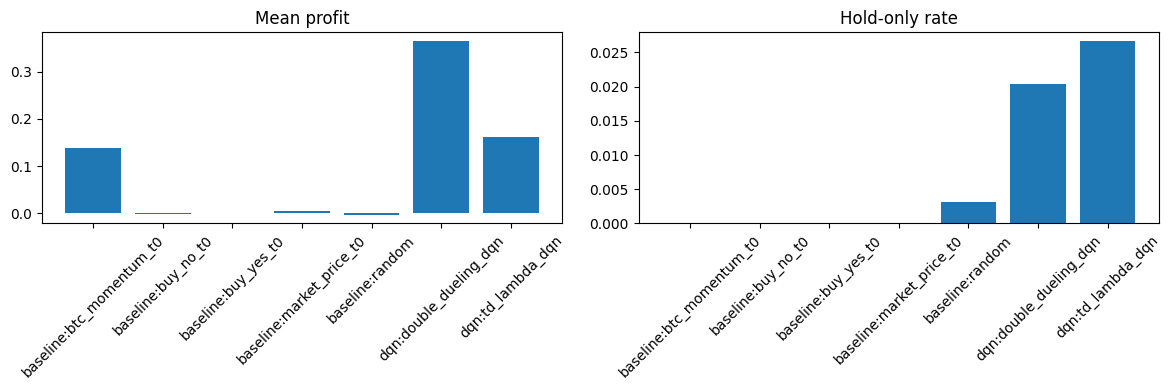

In [9]:
# 9. Plot and Optional Download
import matplotlib.pyplot as plt

if "result_df" in globals() and len(result_df):
    plot_summary_cols = ["mean_profit", "win_rate", "sharpe_like", "avg_buy_up", "avg_buy_down", "hold_only_rate"]
    summary = result_df.groupby(["kind", "policy"])[plot_summary_cols].mean().reset_index()
    display(summary.sort_values("mean_profit", ascending=False))
    labels = summary["kind"] + ":" + summary["policy"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(labels, summary["mean_profit"])
    axes[0].set_title("Mean profit")
    axes[0].tick_params(axis="x", rotation=45)
    axes[1].bar(labels, summary["hold_only_rate"])
    axes[1].set_title("Hold-only rate")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

DOWNLOAD_OUTPUT_ZIP = False
if IN_COLAB and DOWNLOAD_OUTPUT_ZIP:
    import shutil
    zip_path = shutil.make_archive(str(PROJECT_ROOT / "btc_5m_td_lambda_dqn_outputs"), "zip", OUTPUT_DIR)
    files.download(zip_path)
